## Importation des dépendances utilisées par la suite

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans

## Description

Ce projet a pour objectif de **répartir la clientèle d’un centre commercial** afin de mieux comprendre leurs habitudes d’achat.

L’analyse repose sur des méthodes de **machine learning**, notamment des techniques de **clustering**, permettant d’identifier différents profils de clients.

## Métadonnées disponibles

Les données utilisées dans ce projet contiennent les variables suivantes :

- **CustomerID** : identifiant unique du client  
- **Gender** : genre du client  
- **Age** : âge du client  
- **Annual Income (k$)** : revenu annuel du client (en milliers de dollars)  
- **Spending Score (1-100)** : score attribué par le centre commercial représentant le niveau de dépense du client

## Collecte, nettoyage et visualisation des dépendances du jeu de données 

In [7]:
# importation de la dataset localement
customer_data =pd.read_csv('Mall_Customers.csv',sep = ",")

In [8]:
customer_data

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
...,...,...,...,...,...
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18


In [9]:
# visualisation des 5 premières lignes de la dataset
customer_data.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [13]:
# vérification du nombre de lignes et de colonnes du jeu de données
customer_data.shape

(200, 5)

In [14]:
# obtention d’informations relatives à la dataset 
customer_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [ ]:
# premier point d'analyse 
# premier point d’analyse : vérification du nombre de valeurs nulles ou non renseignées présentes dans la dataset
customer_data.isnull().sum()

In [27]:
# sélection des paramètres
X = customer_data.iloc[:,[3,4]].values


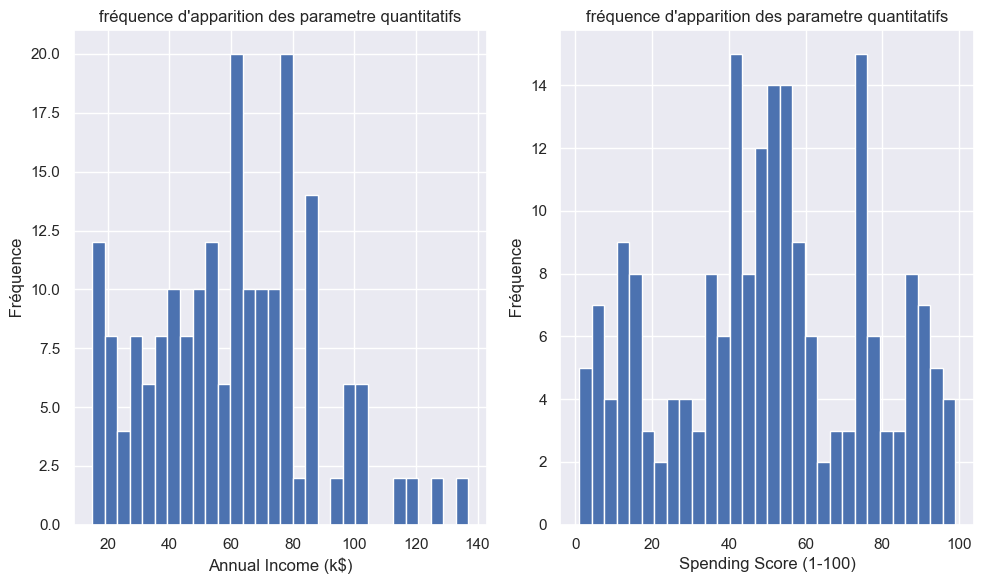

In [43]:
# implémentation de subplots pour visualiser la fréquence d'apparition des paramètres quantitatifs utiles pour réaliser le travail
quant_val = customer_data.iloc[:,[3,4]].columns
fig, axs = plt.subplots(nrows=1, ncols= 2, figsize= (10,6))
axs = axs.flatten()
for i, var in enumerate (quant_val):
    axs[i].hist(customer_data[var], bins = 30)
    axs[i].set_title("fréquence d'apparition des parametre quantitatifs")
    axs[i].set_xlabel(var) 
    axs[i].set_ylabel(' Fréquence ')
plt.tight_layout()
plt.show()

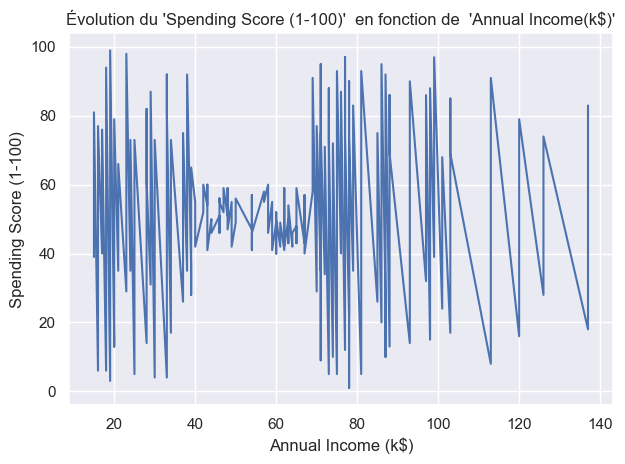

In [55]:
# visualisation de l'évolution du paramètre "Spending Score (1-100)" en fonction de "Annual Income(k$)"
plt.plot (customer_data.iloc[:,[3]].values, customer_data.iloc[:,[4]].values)
plt.xlabel(customer_data.iloc[:,[3]].columns[0])
plt.ylabel(customer_data.iloc[:,[4]].columns[0])
plt.title("Évolution du 'Spending Score (1-100)'  en fonction de  'Annual Income(k$)'")
plt.tight_layout()

In [53]:
# Calcul du nombre optimal de clusters pour la segmentation
wcss = []

# On teste plusieurs valeurs de clusters (de 1 à 10)
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(X) 
    
    # On stocke la somme des distances intra-cluster (WCSS)
    wcss.append(kmeans.inertia_) 

C:\Users\couli\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\couli\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\couli\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\couli\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Window

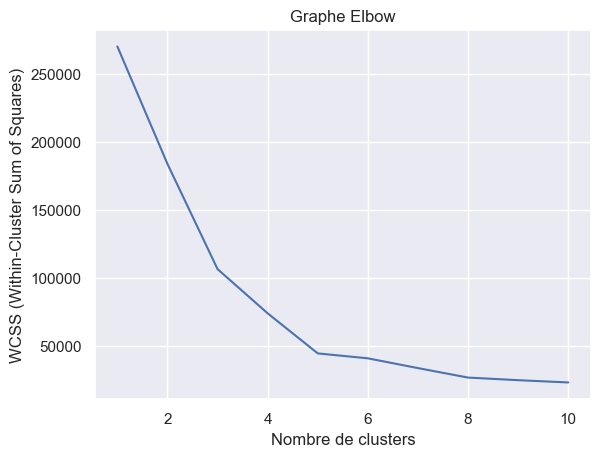

In [22]:
# Visualisation du graphe Elbow pour déterminer le nombre optimal de clusters
plt.plot(range(1,11), wcss)
plt.title('Graphe Elbow')
plt.xlabel('Nombre de clusters')
plt.ylabel('WCSS (Within-Cluster Sum of Squares)')
plt.show() 

In [40]:
# Le graphe de la méthode Elbow indique que le nombre optimal de clusters est de 5.
# Après cette valeur, la diminution du WCSS devient moins significative.
kmeans = KMeans(n_clusters=5, init='k-means++', random_state=0)
Y= kmeans.fit_predict(X)

C:\Users\couli\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


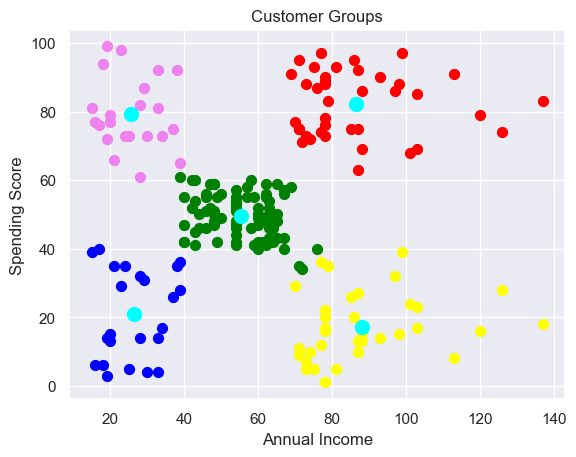

In [41]:
# visualisation des clusters ainsi que leurs centroides
plt.plot(figsize=(8,8) )
plt.scatter(X[Y==0,0], X[Y==0,1], s=50, c='green', label = 'Cluster 1')
plt.scatter(X[Y==1,0], X[Y==1,1], s=50, c='red', label = 'Cluster 2')
plt.scatter(X[Y==2,0], X[Y==2,1], s=50, c='yellow', label = 'Cluster 3')
plt.scatter(X[Y==3,0], X[Y==3,1], s=50, c='blue', label = 'Cluster 4')
plt.scatter(X[Y==4,0], X[Y==4,1], s=50, c='violet', label = 'Cluster 5')

#implémentation des centroïdes
plt.scatter(kmeans.cluster_centers_[:,0], kmeans.cluster_centers_[:,1], s=100, c='cyan', label = 'Centroids')
plt.title('Customer Groups')
plt.xlabel('Annual Income')
plt.ylabel('Spending Score')
plt.show()


In [54]:
# Conclusion
# Le graphe présente le nuage de points catégorisant la clientèle d’un centre commercial
# en fonction de leur revenu annuel (Annual Income) et de leur score de dépense (Spending Score).
# Chaque couleur correspond à un cluster identifié par l'algorithme K-Means, permettant
# d’identifier différents profils de clients et leurs comportements d’achat.